# Evaluation Notebook — Citation Visibility Analysis

Evaluates the effect of GEO edits on citation visibility in LLM-generated product recommendations. All 21 GEO methods are compared against the baseline (`doc` = original, unedited document) on the target document's citation rank in the LLM response.

**Input:**
- `data/retail/generation/4_generation_results_v3.parquet` — LLM generation results with citation orders per query-method combination

**Preprocessing:** Only queries where all 22 methods produced exactly 10 retrieved documents are retained, ensuring full comparability across all pairwise method comparisons (500 → 402 queries).

## Structure
1. **Setup** — imports and paths
2. **Load Data & Preprocessing** — derive outcome variables (`target_retrieval_rank`, `target_citation_rank`, `target_cited`), filter to complete queries
3. **Supporting Analysis** — tests whether retrieval rank predicts citation rank (Kendall's τ-c, baseline only, N = 402)
4. **Hypothese 2** — tests whether GEO edits improve citation visibility (Wilcoxon signed-rank, 21 methods vs. baseline, N = 402 paired queries)

## 1. Setup

Imports all required libraries and defines file paths.

Paths are built relative to the current notebook directory (`os.getcwd()`). The project root sits two levels above the notebook, so all data paths resolve correctly regardless of where the project is stored on disk.

In [19]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.stats import wilcoxon, chi2          # wilcoxon: signed-rank test; chi2: Brant test
from statsmodels.stats.multitest import multipletests  # Bonferroni-Holm correction

# Project root is two levels up
notebook_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(notebook_dir, "..", ".."))
data_dir     = os.path.join(project_root, "data", "retail")

print("Setup complete.")

Setup complete.


## 2. Load Data & Preprocessing

Loads the generation results from parquet and prepares the main DataFrame.

- `target_retrieval_rank`: 1-based retrieval rank of the target document (derived from `target_new_position`)
- `target_citation_rank`: 1-based position at which the target was cited in the LLM response (1–10); non-cited → penalty rank 11
- `target_cited`: binary flag (1 = cited, 0 = not cited)
- Preprocessing: keeps only queries with exactly 10 documents **and** all 22 methods present

In [20]:
EXPECTED_METHODS = 22  # 21 GEO methods + baseline "doc"

# ── Load generation results ───────────────────────────────────────────────────
results_path = os.path.join(data_dir, "generation/4_generation_results_v3.parquet")
df = pd.read_parquet(results_path)

df["citation_order"] = df["citation_order"].apply(
    lambda x: x.tolist() if isinstance(x, np.ndarray) else x
)

# ── Derived columns ───────────────────────────────────────────────────────────
# citation_order and target_new_position are 0-based identifiers (from parquet).
# Documents were passed to the LLM in retrieval order, so:
#   target_new_position (0-based) = retrieval rank - 1
#   target_retrieval_rank is the 1-based retrieval rank, derived directly.
df["target_retrieval_rank"] = df["target_new_position"] + 1  # 1-based, 1–10

# 1 if target document was cited anywhere in the LLM response, else 0
df["target_cited"] = df.apply(
    lambda row: 1 if row["target_new_position"] in row["citation_order"] else 0, axis=1
)

def get_citation_rank(row):
    """
    1-based citation position of the target document (1 = cited first).
    Non-cited documents receive penalty rank 11 (one beyond the max of 10).
    """
    order  = row["citation_order"]
    target = row["target_new_position"]
    if target in order:
        return order.index(target) + 1
    return 11

df["target_citation_rank"] = df.apply(get_citation_rank, axis=1)

# ── Preprocessing ─────────────────────────────────────────────────────────────
# Keep only queries with exactly 10 docs AND all 22 methods present
docs_per_query    = df.groupby("original_query_id")["num_docs"].min()
methods_per_query = df.groupby("original_query_id")["method"].nunique()

complete_queries = (
    set(docs_per_query[docs_per_query == 10].index)
    & set(methods_per_query[methods_per_query == EXPECTED_METHODS].index)
)

n_before = df["original_query_id"].nunique()
df       = df[df["original_query_id"].isin(complete_queries)].reset_index(drop=True)
n_after  = df["original_query_id"].nunique()

df_baseline = df[df["method"] == "doc"].reset_index(drop=True)
all_methods = sorted([m for m in df["method"].unique() if m != "doc"])

print(f"Preprocessing: {n_before} → {n_after} queries ({n_before - n_after} removed)")
print(f"Total rows: {len(df)} | Baseline: {len(df_baseline)} | Methods: {len(all_methods)}")
print(f"Rows with retrieval rank: {df['target_retrieval_rank'].notna().sum()}")

Preprocessing: 500 → 402 queries (98 removed)
Total rows: 8844 | Baseline: 402 | Methods: 21
Rows with retrieval rank: 8844


Quick check — verify column names, dtypes, and that derived columns look correct.

In [21]:
df.head()

,query_id,original_query_id,method,query,target_new_position,num_docs,citation_order,llm_response,target_retrieval_rank,target_cited,target_citation_rank
0,100162_Authoritative(doc),100162,Authoritative(doc),table lamps for bedroom,7,10,"[0, 1, 3, 5, 4, 8, 7]",When searching for table lamps suitable for a ...,8,1,7
1,100162_CQ(doc),100162,CQ(doc),table lamps for bedroom,9,10,"[0, 1, 2, 4, 5, 6, 7]","When selecting a table lamp for your bedroom, ...",10,0,11
2,100162_CQS(doc),100162,CQS(doc),table lamps for bedroom,9,10,"[0, 1, 6, 2, 4, 5, 9]","When looking for table lamps for your bedroom,...",10,1,7
3,100162_CS(doc),100162,CS(doc),table lamps for bedroom,9,10,"[0, 5, 1, 3, 4, 9, 7]","When looking for table lamps for your bedroom,...",10,1,6
4,100162_Citations(doc),100162,Citations(doc),table lamps for bedroom,8,10,"[0, 1, 2, 3, 5, 6]",When looking for table lamps suitable for a be...,9,0,11


Quick sanity check on the loaded data — expected dimensions and LLM response length to catch truncation or empty outputs.

In [22]:
print("=" * 50)
print("QUICK CHECK")
print("=" * 50)

# Dataset overview
print(f"Total runs:              {len(df)}")
print(f"Unique original queries: {df['original_query_id'].nunique()}")
print(f"Unique methods:          {df['method'].nunique()}")

# LLM response length — sanity check for truncation or empty responses
df["response_length"] = df["llm_response"].apply(lambda x: len(x.split()))
print(f"\nLLM Response Length (words):")
print(f"  Mean:   {df['response_length'].mean():.1f}")
print(f"  Median: {df['response_length'].median():.0f}")
print(f"  Min:    {df['response_length'].min()}")
print(f"  Max:    {df['response_length'].max()}")


QUICK CHECK
Total runs:              8844
Unique original queries: 402
Unique methods:          22

LLM Response Length (words):
  Mean:   328.2
  Median: 336
  Min:    53
  Max:    532


## 3. Supporting Analysis

Tests whether retrieval rank is monotonically associated with citation rank (baseline only, N = 402) using Kendall's τ-c.

The descriptive tables characterize the marginal distributions of both variables. The Brant test rules out ordinal logistic regression (proportional odds assumption violated), and MNLogit fails due to near-empty outcome categories — both analyses lead to Kendall's τ-c as the appropriate nonparametric test.

### Descriptive Analysis

Three tables characterizing the baseline sample (N = 402):
- **Table 1** — marginal distribution of `target_retrieval_rank` (1–10)
- **Table 2** — marginal distribution of `target_citation_rank` (1–10; penalty rank 11 = not cited)
- **Table 3** — median citation rank and % not cited broken down by retrieval rank; shows the core monotonic pattern

In [23]:
df_baseline_sa = df[df["method"] == "doc"].copy()  # sa = supporting analysis (baseline only)

# ── Table 1: Retrieval Rank Distribution ─────────────────────────────────────
rr        = df_baseline_sa["target_retrieval_rank"]
median_rr = rr.median()
q25_rr    = rr.quantile(0.25)
q75_rr    = rr.quantile(0.75)
iqr_rr    = q75_rr - q25_rr

print("=" * 60)
print(f"TABLE 1 — Retrieval Rank Distribution (Baseline-Only, N={len(df_baseline_sa)})")
print("Position of target document in Vertex AI Search results.")
print("=" * 60)
print(f"  Median: {median_rr:.1f}  |  Q25: {q25_rr:.1f}  |  Q75: {q75_rr:.1f}  |  IQR: {iqr_rr:.1f}")
print()
print(f"  {'Retrieval Rank':>15} {'N':>5} {'%':>8}")
print("  " + "-" * 30)
for rank, grp in df_baseline_sa.groupby("target_retrieval_rank"):
    n   = len(grp)
    pct = n / len(df_baseline_sa) * 100
    print(f"  {int(rank):>15} {n:>5} {pct:>7.1f}%")

# ── Table 2: Citation Rank Distribution ──────────────────────────────────────
cr          = df_baseline_sa["target_citation_rank"]
median_cr   = cr.median()
q25_cr      = cr.quantile(0.25)
q75_cr      = cr.quantile(0.75)
iqr_cr      = q75_cr - q25_cr
pct_penalty = (cr == 11).mean() * 100

print()
print("=" * 60)
print(f"TABLE 2 — Citation Rank Distribution (Baseline-Only, N={len(df_baseline_sa)})")
print("Non-cited documents receive fixed penalty rank 11.")
print("=" * 60)
print(f"  Median: {median_cr:.1f}  |  Q25: {q25_cr:.1f}  |  Q75: {q75_cr:.1f}  |  IQR: {iqr_cr:.1f}")
print(f"  Not Cited (Rank 11): {pct_penalty:.1f}%")
print()
print(f"  {'Citation Rank':>15} {'N':>5} {'%':>8}")
print("  " + "-" * 30)
for rank, grp in df_baseline_sa.groupby("target_citation_rank"):
    n   = len(grp)
    pct = n / len(df_baseline_sa) * 100
    print(f"  {int(rank):>15} {n:>5} {pct:>7.1f}%")

# ── Table 3: Median Citation Rank per Retrieval Rank ─────────────────────────
print()
print("=" * 65)
print(f"TABLE 3 — Median Citation Rank per Retrieval Rank (Baseline-Only, N={len(df_baseline_sa)})")
print("=" * 65)
print(f"  {'Retrieval Rank':>15} {'N':>5} {'Median Citation Rank':>22} {'% Not Cited':>13}")
print("-" * 65)
for rank, grp in df_baseline_sa.groupby("target_retrieval_rank"):
    n             = len(grp)
    median_cr_r   = grp["target_citation_rank"].median()
    pct_not_cited = (grp["target_citation_rank"] == 11).mean() * 100
    print(f"  {int(rank):>15} {n:>5} {median_cr_r:>22.1f} {pct_not_cited:>12.1f}%")

TABLE 1 — Retrieval Rank Distribution (Baseline-Only, N=402)
Position of target document in Vertex AI Search results.
  Median: 6.0  |  Q25: 3.0  |  Q75: 8.0  |  IQR: 5.0

   Retrieval Rank     N        %
  ------------------------------
                1    38     9.5%
                2    42    10.4%
                3    37     9.2%
                4    29     7.2%
                5    50    12.4%
                6    46    11.4%
                7    35     8.7%
                8    39     9.7%
                9    40    10.0%
               10    46    11.4%

TABLE 2 — Citation Rank Distribution (Baseline-Only, N=402)
Non-cited documents receive fixed penalty rank 11.
  Median: 6.0  |  Q25: 3.0  |  Q75: 11.0  |  IQR: 8.0
  Not Cited (Rank 11): 35.6%

    Citation Rank     N        %
  ------------------------------
                1    36     9.0%
                2    47    11.7%
                3    32     8.0%
                4    39     9.7%
                5    39     9.7%
     

**Retrieval rank (Table 1)** is roughly uniformly distributed across positions 1–10 (Median = 6, IQR = 5), confirming that there is no systematic placement bias in how often the target lands at any given retrieval position.

**Citation rank (Table 2)** is bimodal: observations cluster at early citation positions (ranks 1–6) and spike sharply at the penalty rank 11 (35.6% not cited), with very few observations at ranks 7–10. This reflects the LLM's tendency to either cite a document prominently or skip it entirely.

**Table 3** shows a clear monotonic gradient: targets retrieved at rank 1 have a median citation rank of 1 (7.9% not cited), while targets retrieved at rank 10 have a median citation rank of 11 (58.7% not cited). This pattern motivates the Kendall's τ-c test below.

### Scatterplot with LOWESS

Visualizes the relationship between retrieval rank (x) and citation rank (y) for baseline runs only.

Three visual layers:
- **Points (jittered):** Both variables are discrete integers (1–10 / 1–11), so without jitter all observations at the same coordinate would fully overlap. Uniform noise of ±0.2 is added to each axis for visibility.
- **LOWESS trend (red):** A non-parametric local smoother — does not assume linearity, which is appropriate given the Brant test result showing that the proportional odds assumption is violated.
- **Median per retrieval rank (orange dashed):** Concrete reference from Table 3, overlaid to anchor the smooth trend to the actual group medians.

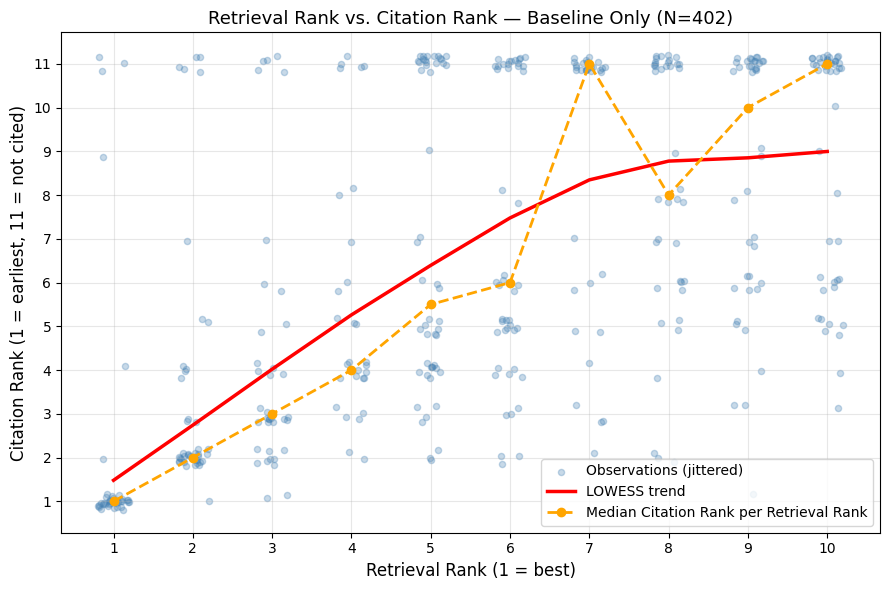

In [24]:
from statsmodels.nonparametric.smoothers_lowess import lowess

fig, ax = plt.subplots(figsize=(9, 6))

jitter_x = np.random.uniform(-0.2, 0.2, size=len(df_baseline_sa))
jitter_y = np.random.uniform(-0.2, 0.2, size=len(df_baseline_sa))

ax.scatter(
    df_baseline_sa["target_retrieval_rank"] + jitter_x,
    df_baseline_sa["target_citation_rank"] + jitter_y,
    alpha=0.3, s=20, color="steelblue", label="Observations (jittered)"
)

smoothed = lowess(
    df_baseline_sa["target_citation_rank"],
    df_baseline_sa["target_retrieval_rank"],
    frac=0.5
)
ax.plot(smoothed[:, 0], smoothed[:, 1], color="red", linewidth=2.5, label="LOWESS trend")

median_by_rank = df_baseline_sa.groupby("target_retrieval_rank")["target_citation_rank"].median()
ax.plot(median_by_rank.index, median_by_rank.values,
        color="orange", linewidth=2, linestyle="--",
        marker="o", markersize=6, label="Median Citation Rank per Retrieval Rank")

ax.set_xlabel("Retrieval Rank (1 = best)", fontsize=12)
ax.set_ylabel("Citation Rank (1 = earliest, 11 = not cited)", fontsize=12)
ax.set_title(f"Retrieval Rank vs. Citation Rank — Baseline Only (N={len(df_baseline_sa)})", fontsize=13)
ax.set_xticks(range(1, 11))
ax.set_yticks(range(1, 12))
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


The LOWESS trend confirms a positive monotonic relationship: as retrieval rank worsens, citation rank increases. The relationship is approximately linear for retrieval ranks 1–6, where the median citation rank tracks the retrieval rank closely. Around rank 7, the curve steepens sharply — targets at retrieval rank 7 have a median citation rank of 11 (68.6% not cited), a notable discontinuity relative to the otherwise smooth gradient.

This non-linearity is consistent with the Brant test result: the effect of retrieval rank on citation rank is not uniform across the outcome scale, which is precisely why ordinal logistic regression is not appropriate here.

### Brant Test

Tests whether the proportional odds assumption of ordinal logistic regression holds — i.e., whether the effect of `target_retrieval_rank` on `target_citation_rank` is consistent across all cutpoints of the outcome scale.

The code proceeds in two steps:
1. **Pooled coefficient:** Fit a proportional odds model (ordinal logit) to obtain a single β₁ that assumes the effect is constant across cutpoints.
2. **Per-cutpoint coefficients:** For each cutpoint k (1–10), binarise the outcome as `y = (target_citation_rank ≤ k)` and fit a separate binary logistic regression. If proportional odds holds, these per-cutpoint β₁ values should be stable around the pooled estimate.

A chi-squared statistic (df = J − 2 = 9) tests whether the observed variation across cutpoints exceeds what is expected under H₀. A p-value shown as `< 1e-300` means the statistic exceeds floating-point precision — the violation is unambiguous, not a rounding artefact.

In [25]:
from statsmodels.miscmodels.ordinal_model import OrderedModel
import statsmodels.api as sm
from scipy.stats import chi2

# Fit proportional odds model internally to obtain pooled coefficient
ordered_result = OrderedModel(
    df_baseline_sa["target_citation_rank"].astype(int),
    df_baseline_sa[["target_retrieval_rank"]],
    distr="logit"
).fit(method="bfgs", disp=False)

beta_pooled = ordered_result.params["target_retrieval_rank"]
var_pooled  = ordered_result.cov_params().loc["target_retrieval_rank", "target_retrieval_rank"]

# Fit separate binary logit per cutpoint k: P(target_citation_rank <= k)
X = sm.add_constant(df_baseline_sa["target_retrieval_rank"].values)

coefs = []
for k in sorted(df_baseline_sa["target_citation_rank"].unique())[:-1]:
    y_binary = (df_baseline_sa["target_citation_rank"] <= k).astype(int)
    if y_binary.sum() < 5 or (1 - y_binary).sum() < 5:
        continue
    try:
        res = sm.Logit(y_binary, X).fit(disp=0)
        coefs.append({"cutpoint": int(k), "coef": res.params[1], "se": res.bse[1]})
    except:
        pass

df_coefs = pd.DataFrame(coefs)

# Chi-squared statistic: W = sum((β_j - β_pooled)² / SE_j²)
# Tests whether coefficients are homogeneous across cutpoints
W       = ((df_coefs["coef"] - beta_pooled) ** 2 / df_coefs["se"] ** 2).sum()
df_test = len(df_coefs) - 1
p_brant = chi2.sf(W, df=df_test)  # sf = 1 - cdf, numerically stable for large W

print("=" * 60)
print("Brant Test — Proportional Odds Assumption")
print("H0: β₁ is equal across all cutpoints")
print("=" * 60)
print(f"  Pooled β₁ (ordinal model): {beta_pooled:.4f}  (SE: {var_pooled**0.5:.4f})")
print()
print(f"  {'Cutpoint k':>10} {'β₁':>10} {'SE':>10}")
print("  " + "-" * 32)
for _, row in df_coefs.iterrows():
    print(f"  {row['cutpoint']:>10} {row['coef']:>10.4f} {row['se']:>10.4f}")
print()
print(f"  Mean β₁: {df_coefs['coef'].mean():.4f}")
print(f"  Std β₁:  {df_coefs['coef'].std():.4f}")
print(f"  Range:   {df_coefs['coef'].min():.4f} to {df_coefs['coef'].max():.4f}")
print()
print(f"  Chi-squared: {W:.3f}")
print(f"  df:          {df_test}")
p_str = "< 1e-300 (beyond float precision)" if p_brant == 0.0 else (f"{p_brant:.2e}" if p_brant < 0.001 else f"{p_brant:.4f}")
print(f"  p-value:     {p_str}  {'→ Proportional odds VIOLATED' if p_brant < 0.05 else '→ Proportional odds holds'}")


Brant Test — Proportional Odds Assumption
H0: β₁ is equal across all cutpoints
  Pooled β₁ (ordinal model): 0.5161  (SE: 0.0413)

  Cutpoint k         β₁         SE
  --------------------------------
         1.0    -1.9146     0.3389
         2.0    -0.8143     0.0929
         3.0    -0.6275     0.0655
         4.0    -0.5986     0.0587
         5.0    -0.4682     0.0485
         6.0    -0.3629     0.0435
         7.0    -0.3396     0.0430
         8.0    -0.3141     0.0426
         9.0    -0.3060     0.0426
        10.0    -0.2993     0.0424

  Mean β₁: -0.6045
  Std β₁:  0.4916
  Range:   -1.9146 to -0.2993

  Chi-squared: 3260.986
  df:          9
  p-value:     < 1e-300 (beyond float precision)  → Proportional odds VIOLATED


/var/folders/lf/6rsckgz10_93vpjm3kxh6b5h0000gn/T/ipykernel_52085/852326448.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coefs.append({"cutpoint": int(k), "coef": res.params[1], "se": res.bse[1]})
/var/folders/lf/6rsckgz10_93vpjm3kxh6b5h0000gn/T/ipykernel_52085/852326448.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  coefs.append({"cutpoint": int(k), "coef": res.params[1], "se": res.bse[1]})
/var/folders/lf/6rsckgz10_93vpjm3kxh6b5h0000gn/T/ipykernel_52085/852326448.py:25: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated a

The per-cutpoint coefficients vary substantially — from β₁ = −1.91 at cutpoint k = 1 to β₁ = −0.30 at cutpoint k = 10, a more than sixfold range. This means the effect of retrieval rank on the probability of being cited changes dramatically depending on where on the outcome scale we draw the threshold.

The chi-squared statistic is 3261 on 9 degrees of freedom (p < 1e-300), far beyond any conventional significance threshold. **The proportional odds assumption is clearly violated.** Ordinal logistic regression is therefore not appropriate here, and Kendall's τ-c is used as the inferential test instead.

### Multinomial Logistic Regression

Tested as an alternative to ordinal logistic regression after the Brant test showed that proportional odds is violated. Unlike OLR, MNLogit estimates a separate coefficient for each outcome category (except the reference), making no assumption about the ordering of categories.

The code fits MNLogit with `target_retrieval_rank` as the single predictor and `target_citation_rank` (11 categories) as the outcome, then prints the full coefficient table and standard errors per category.

In [26]:
from statsmodels.discrete.discrete_model import MNLogit

X = sm.add_constant(df_baseline_sa["target_retrieval_rank"].values)
y = df_baseline_sa["target_citation_rank"].values

try:
    model  = MNLogit(y, X)
    result = model.fit(disp=0)
    print(result.summary())
    print()
    print("Standard Errors per Category:")
    print(result.bse)
except Exception as e:
    print(f"Model failed: {e}")


/opt/anaconda3/envs/seo_geo_env/lib/python3.10/site-packages/statsmodels/discrete/discrete_model.py:3027: RuntimeWarning: overflow encountered in exp
  eXB = np.column_stack((np.ones(len(X)), np.exp(X)))
/opt/anaconda3/envs/seo_geo_env/lib/python3.10/site-packages/statsmodels/discrete/discrete_model.py:3028: RuntimeWarning: invalid value encountered in divide
  return eXB/eXB.sum(1)[:,None]


                          MNLogit Regression Results                          
Dep. Variable:                      y   No. Observations:                  402
Model:                        MNLogit   Df Residuals:                      382
Method:                           MLE   Df Model:                           10
Date:                Wed, 13 May 2026   Pseudo R-squ.:                     nan
Time:                        07:41:21   Log-Likelihood:                    nan
converged:                       True   LL-Null:                       -801.36
Covariance Type:            nonrobust   LLR p-value:                       nan
       y=2       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const             nan        nan        nan        nan         nan         nan
x1                nan        nan        nan        nan         nan         nan
----------------------------------------------------

All parameters and standard errors are NaN — the model failed to produce stable estimates. The cause is a data structure problem: citation rank 10 contains only 1 observation, and ranks 8 and 9 have 12 and 6 observations respectively. With near-empty categories and a single predictor, the softmax computation overflows during MLE optimisation.

MNLogit is not viable here. Kendall's τ-c is used as the inferential test instead.

### Kendall's τ-c

Tests whether retrieval rank and citation rank are monotonically associated (baseline only). τ-c is chosen over τ-b because the two variables have asymmetric scales (retrieval rank 1–10, citation rank 1–11) and both contain substantial ties due to the discrete nature of rank data.

For τ-c to be preferred over τ-b, ties must be substantial in both variables. The code counts the number of tied pairs (pairs of observations sharing the same rank value) for `target_retrieval_rank` and `target_citation_rank`, and expresses each as a share of all possible pairs N(N−1)/2.

In [27]:
rr_counts = df_baseline_sa["target_retrieval_rank"].value_counts().sort_index()
rr_ties   = (rr_counts * (rr_counts - 1) / 2).sum()

cr_counts = df_baseline_sa["target_citation_rank"].value_counts().sort_index()
cr_ties   = (cr_counts * (cr_counts - 1) / 2).sum()

n           = len(df_baseline_sa)
total_pairs = n * (n - 1) / 2

print("=" * 55)
print(f"Tie Analysis — Baseline-Only (N={n})")
print("=" * 55)
print(f"\nRetrieval Rank:")
print(f"  Tie pairs:     {int(rr_ties):>6}")
print(f"  % of all pairs: {rr_ties/total_pairs*100:>5.1f}%")
print(f"\nCitation Rank:")
print(f"  Tie pairs:     {int(cr_ties):>6}")
print(f"  % of all pairs: {cr_ties/total_pairs*100:>5.1f}%")
print(f"\nTotal possible pairs: {int(total_pairs)}")


Tie Analysis — Baseline-Only (N=402)

Retrieval Rank:
  Tie pairs:       8047
  % of all pairs:  10.0%

Citation Rank:
  Tie pairs:      14542
  % of all pairs:  18.0%

Total possible pairs: 80601


Ties are substantial in both variables: 10.0% of all pairs are tied on retrieval rank and 18.0% on citation rank (the latter inflated by the 143 observations sharing the penalty rank 11). This confirms that τ-c is the appropriate variant — τ-b would underestimate the association by not accounting for the asymmetric table dimensions.

The code computes Kendall's τ-c using `scipy.stats.kendalltau` with `variant="c"`, derives the Gilpin (1993) effect size r = sin(0.5π τ-c), and constructs a 95% bootstrap confidence interval by resampling the 402 observation pairs 10,000 times.

In [28]:
from scipy.stats import kendalltau

np.random.seed(42)

rr = df_baseline_sa["target_retrieval_rank"].values
cr = df_baseline_sa["target_citation_rank"].values
N  = len(rr)

tau, pvalue = kendalltau(rr, cr, variant="c")

r_gilpin = np.sin(0.5 * np.pi * tau)

# Bootstrap 95% CI: resample pairs with replacement, recompute τ-c each time
boot_taus = []
for _ in range(10000):
    idx = np.random.choice(N, size=N, replace=True)
    t, _ = kendalltau(rr[idx], cr[idx], variant="c")
    boot_taus.append(t)
ci_lower, ci_upper = np.percentile(boot_taus, [2.5, 97.5])

def cohen_r(r):
    a = abs(r)
    if a < 0.1:  return "negligible"
    if a < 0.3:  return "small"
    if a < 0.5:  return "medium"
    return "large"

p_str = "< 1e-300 (beyond float precision)" if pvalue == 0.0 else (f"{pvalue:.2e}" if pvalue < 0.001 else f"{pvalue:.4f}")

print("=" * 60)
print("Kendall's τ-c: Retrieval Rank → Citation Rank")
print(f"Baseline-only (N={N})")
print("=" * 60)
print(f"  τ-c:          {tau:>8.4f}  95% CI [{ci_lower:+.4f}, {ci_upper:+.4f}]")
print(f"  p-value:      {p_str}  {'*' if pvalue < 0.05 else 'ns'}")
print(f"  r (Gilpin):   {r_gilpin:>8.4f}  [{cohen_r(r_gilpin)}, Cohen 1992]")
print()
if pvalue < 0.05 and tau > 0:
    print("→ Significant positive association.")
    print("  A worse retrieval rank is associated with a later citation rank.")
elif pvalue < 0.05 and tau < 0:
    print("→ Significant negative association — unexpected direction.")
else:
    print("→ No significant association detected.")
print()
print("τ-c: -1 to +1. Positive = worse retrieval → later citation.")
print("95% CI via bootstrap (10,000 iterations, seed 42).")
print("r = sin(0.5 π τ-c) — Gilpin (1993). Cohen (1992): <.1 negligible, .1–.3 small, .3–.5 medium, >.5 large.")

Kendall's τ-c: Retrieval Rank → Citation Rank
Baseline-only (N=402)
  τ-c:            0.4670  95% CI [+0.3977, +0.5297]
  p-value:      9.26e-39  *
  r (Gilpin):     0.6696  [large, Cohen 1992]

→ Significant positive association.
  A worse retrieval rank is associated with a later citation rank.

τ-c: -1 to +1. Positive = worse retrieval → later citation.
95% CI via bootstrap (10,000 iterations, seed 42).
r = sin(0.5 π τ-c) — Gilpin (1993). Cohen (1992): <.1 negligible, .1–.3 small, .3–.5 medium, >.5 large.


τ-c = 0.467 (95% CI [+0.398, +0.530]), p = 9.26e-39. The association is positive, statistically significant, and large by Cohen's (1992) benchmarks (r = 0.670). A worse retrieval rank is strongly associated with a later citation rank: documents retrieved near the bottom of the results are substantially less likely to be cited, and when cited, appear later in the LLM response.

This establishes retrieval rank as a strong predictor of citation visibility and motivates the pairwise design in H2, where each GEO method is evaluated against the same baseline query to hold retrieval rank constant.

## Hypothese 2

**H2:** Content-based GEO edits significantly enhance a document's citation visibility within the LLM-generated response.

### Descriptive Analysis

For each of the 21 GEO methods, the code merges baseline and method citation ranks on `original_query_id` to form a paired dataset, then computes the shift (baseline − method) per query. A positive shift means the GEO edit cited the target earlier; a negative shift means it cited it later; zero means no change.

**Table 1 — Distribution Summary:** Median and mean `target_citation_rank` for baseline and method, plus the shift distribution. Zeros and % Zeros quantify how often the GEO edit produced no change — directly relevant to the Wilcoxon Pratt modification, which retains zero differences in the ranking step before exclusion.

**Table 2 — Ranking Performance:** Share of queries where the target appeared in citation positions 1–3 (top-3 rate), and the directional breakdown of shifts (% Improved / Unchanged / Worsened).

In [29]:
# Paired DataFrame: baseline vs. each method
base_cr = (
    df[df["method"] == "doc"][["original_query_id", "target_citation_rank"]]
    .rename(columns={"target_citation_rank": "cr_baseline"})
)

rows = []
for method in all_methods:
    method_cr = (
        df[df["method"] == method][["original_query_id", "target_citation_rank"]]
        .rename(columns={"target_citation_rank": "cr_method"})
    )
    merged           = base_cr.merge(method_cr, on="original_query_id")
    merged["shift"]  = merged["cr_baseline"] - merged["cr_method"]
    merged["method"] = method
    rows.append(merged)

paired_cr = pd.concat(rows, ignore_index=True)

# Helper aggregations
def q25(x):      return x.quantile(0.25)
def q75(x):      return x.quantile(0.75)
def top3_pct(x): return (x <= 3).mean() * 100
def zeros(x):    return (x == 0).sum()
def pct_zeros(x): return (x == 0).mean() * 100

paired_cr["status"] = np.select(
    [paired_cr["shift"] > 0, paired_cr["shift"] < 0],
    ["Improved", "Worsened"],
    default="Unchanged"
)

dist = paired_cr.groupby("method").agg(
    N             = ("original_query_id", "count"),
    Median_Base   = ("cr_baseline",       "median"),
    Median_Method = ("cr_method",         "median"),
    Median_Shift  = ("shift",             "median"),
    Mean_Base     = ("cr_baseline",       "mean"),
    Mean_Method   = ("cr_method",         "mean"),
    Mean_Shift    = ("shift",             "mean"),
    Zeros         = ("shift",             zeros),
    Pct_Zeros     = ("shift",             pct_zeros),
)

perf = paired_cr.groupby("method").agg(
    Top3_Base_Pct = ("cr_baseline", top3_pct),
    Top3_Meth_Pct = ("cr_method",   top3_pct),
)
perf["Top3_Delta"] = perf["Top3_Meth_Pct"] - perf["Top3_Base_Pct"]

status_counts = (
    paired_cr.groupby(["method", "status"])
    .size().unstack(fill_value=0)
    .reindex(columns=["Improved", "Unchanged", "Worsened"], fill_value=0)
)
status_pct = status_counts.div(status_counts.sum(axis=1), axis=0) * 100
status_pct.columns = ["% Improved", "% Unchanged", "% Worsened"]

master = dist.join(perf).join(status_pct)
master = master.sort_values("Mean_Shift", ascending=False)

# Baseline reference
base_vals = df[df["method"] == "doc"]["target_citation_rank"]
base_n    = len(base_vals)
base_med  = base_vals.median()
base_mean = base_vals.mean()
base_top3 = top3_pct(base_vals)

# Table 1 — Distribution Summary
print("=" * 100)
print("TABLE 1 — Distribution Summary  |  Delta Citation Rank = Baseline − Method")
print("Positive shift = improvement. Non-cited documents receive penalty rank 11.")
print("=" * 100)
print(f"  {'Method':<26} {'N':>4}  {'Med.Base':>8} {'Med.Meth':>9} {'Med.Shift':>10}  {'Mean.Base':>9} {'Mean.Meth':>10} {'Mean.Shift':>11}  {'Zeros':>6} {'%Zeros':>7}")
print("-" * 100)
print(f"  {'Baseline (doc)':<26} {base_n:>4}  {base_med:>8.1f} {'—':>9} {'—':>10}  {base_mean:>9.3f} {'—':>10} {'—':>11}  {'—':>6} {'—':>7}")
print()
for method, row in master.iterrows():
    print(f"  {method:<26} {row['N']:>4}  "
          f"{row['Median_Base']:>8.1f} {row['Median_Method']:>9.1f} {row['Median_Shift']:>+10.1f}  "
          f"{row['Mean_Base']:>9.3f} {row['Mean_Method']:>10.3f} {row['Mean_Shift']:>+11.3f}  "
          f"{row['Zeros']:>6.0f} {row['Pct_Zeros']:>6.1f}%")

# Table 2 — Ranking Performance Summary
print()
print("=" * 80)
print("TABLE 2 — Ranking Performance Summary")
print("Top-3% = proportion of queries where target appeared in citation positions 1–3.")
print("=" * 80)
print(f"  {'Method':<26}  {'%Top3.B':>8} {'%Top3.M':>8} {'ΔTop3%':>8}  {'%Impr':>7} {'%Unch':>7} {'%Wors':>7}")
print("-" * 80)
print(f"  {'Baseline (doc)':<26}  {base_top3:>7.1f}% {'—':>8} {'—':>8}  {'—':>7} {'—':>7} {'—':>7}")
print()
for method, row in master.iterrows():
    print(f"  {method:<26}  "
          f"{row['Top3_Base_Pct']:>7.1f}% {row['Top3_Meth_Pct']:>7.1f}% {row['Top3_Delta']:>+7.1f}%  "
          f"{row['% Improved']:>6.1f}% {row['% Unchanged']:>6.1f}% {row['% Worsened']:>6.1f}%")
print()
print("Sorted by Mean Shift descending.")


TABLE 1 — Distribution Summary  |  Delta Citation Rank = Baseline − Method
Positive shift = improvement. Non-cited documents receive penalty rank 11.
  Method                        N  Med.Base  Med.Meth  Med.Shift  Mean.Base  Mean.Meth  Mean.Shift   Zeros  %Zeros
----------------------------------------------------------------------------------------------------
  Baseline (doc)              402       6.0         —          —      6.483          —           —       —       —

  QS(doc)                    402.0       6.0       5.0       +0.0      6.483      6.276      +0.206     174   43.3%
  SimpleLanguage(doc)        402.0       6.0       5.0       +0.0      6.483      6.286      +0.197     153   38.1%
  Quotes(doc)                402.0       6.0       6.0       +0.0      6.483      6.386      +0.097     160   39.8%
  TechnicalTerms(doc)        402.0       6.0       6.0       +0.0      6.483      6.453      +0.030     159   39.6%
  CQS(doc)                   402.0       6.0       6.0

**Table 1:** All 21 methods show a median shift of 0.0 — the distributions are heavily zero-inflated, with 31–43% of query pairs producing no change in citation rank. Mean shifts range from +0.206 (QS) to −1.453 (Statistics). Only QS and SimpleLanguage improve on average; the majority of methods leave citation rank unchanged or worsen it, with F-prefix methods consistently negative.

**Table 2:** The baseline top-3 citation rate is 28.6%. QS shows the largest gain (+4.0 pp to 32.6%), while Statistics(doc) drops by −10.9 pp to 17.7%. The directional breakdown confirms the zero-inflation: 35–44% of queries are unchanged across most methods.

### Symmetry Check

The Wilcoxon signed-rank test assumes that the distribution of pairwise differences is symmetric around the median. The histograms below visualize the full Δ Citation Rank distribution for each method, and the symmetry table tests this assumption formally by computing skewness and a standardised z-score — a method is flagged as asymmetric if |z| > 1.96.

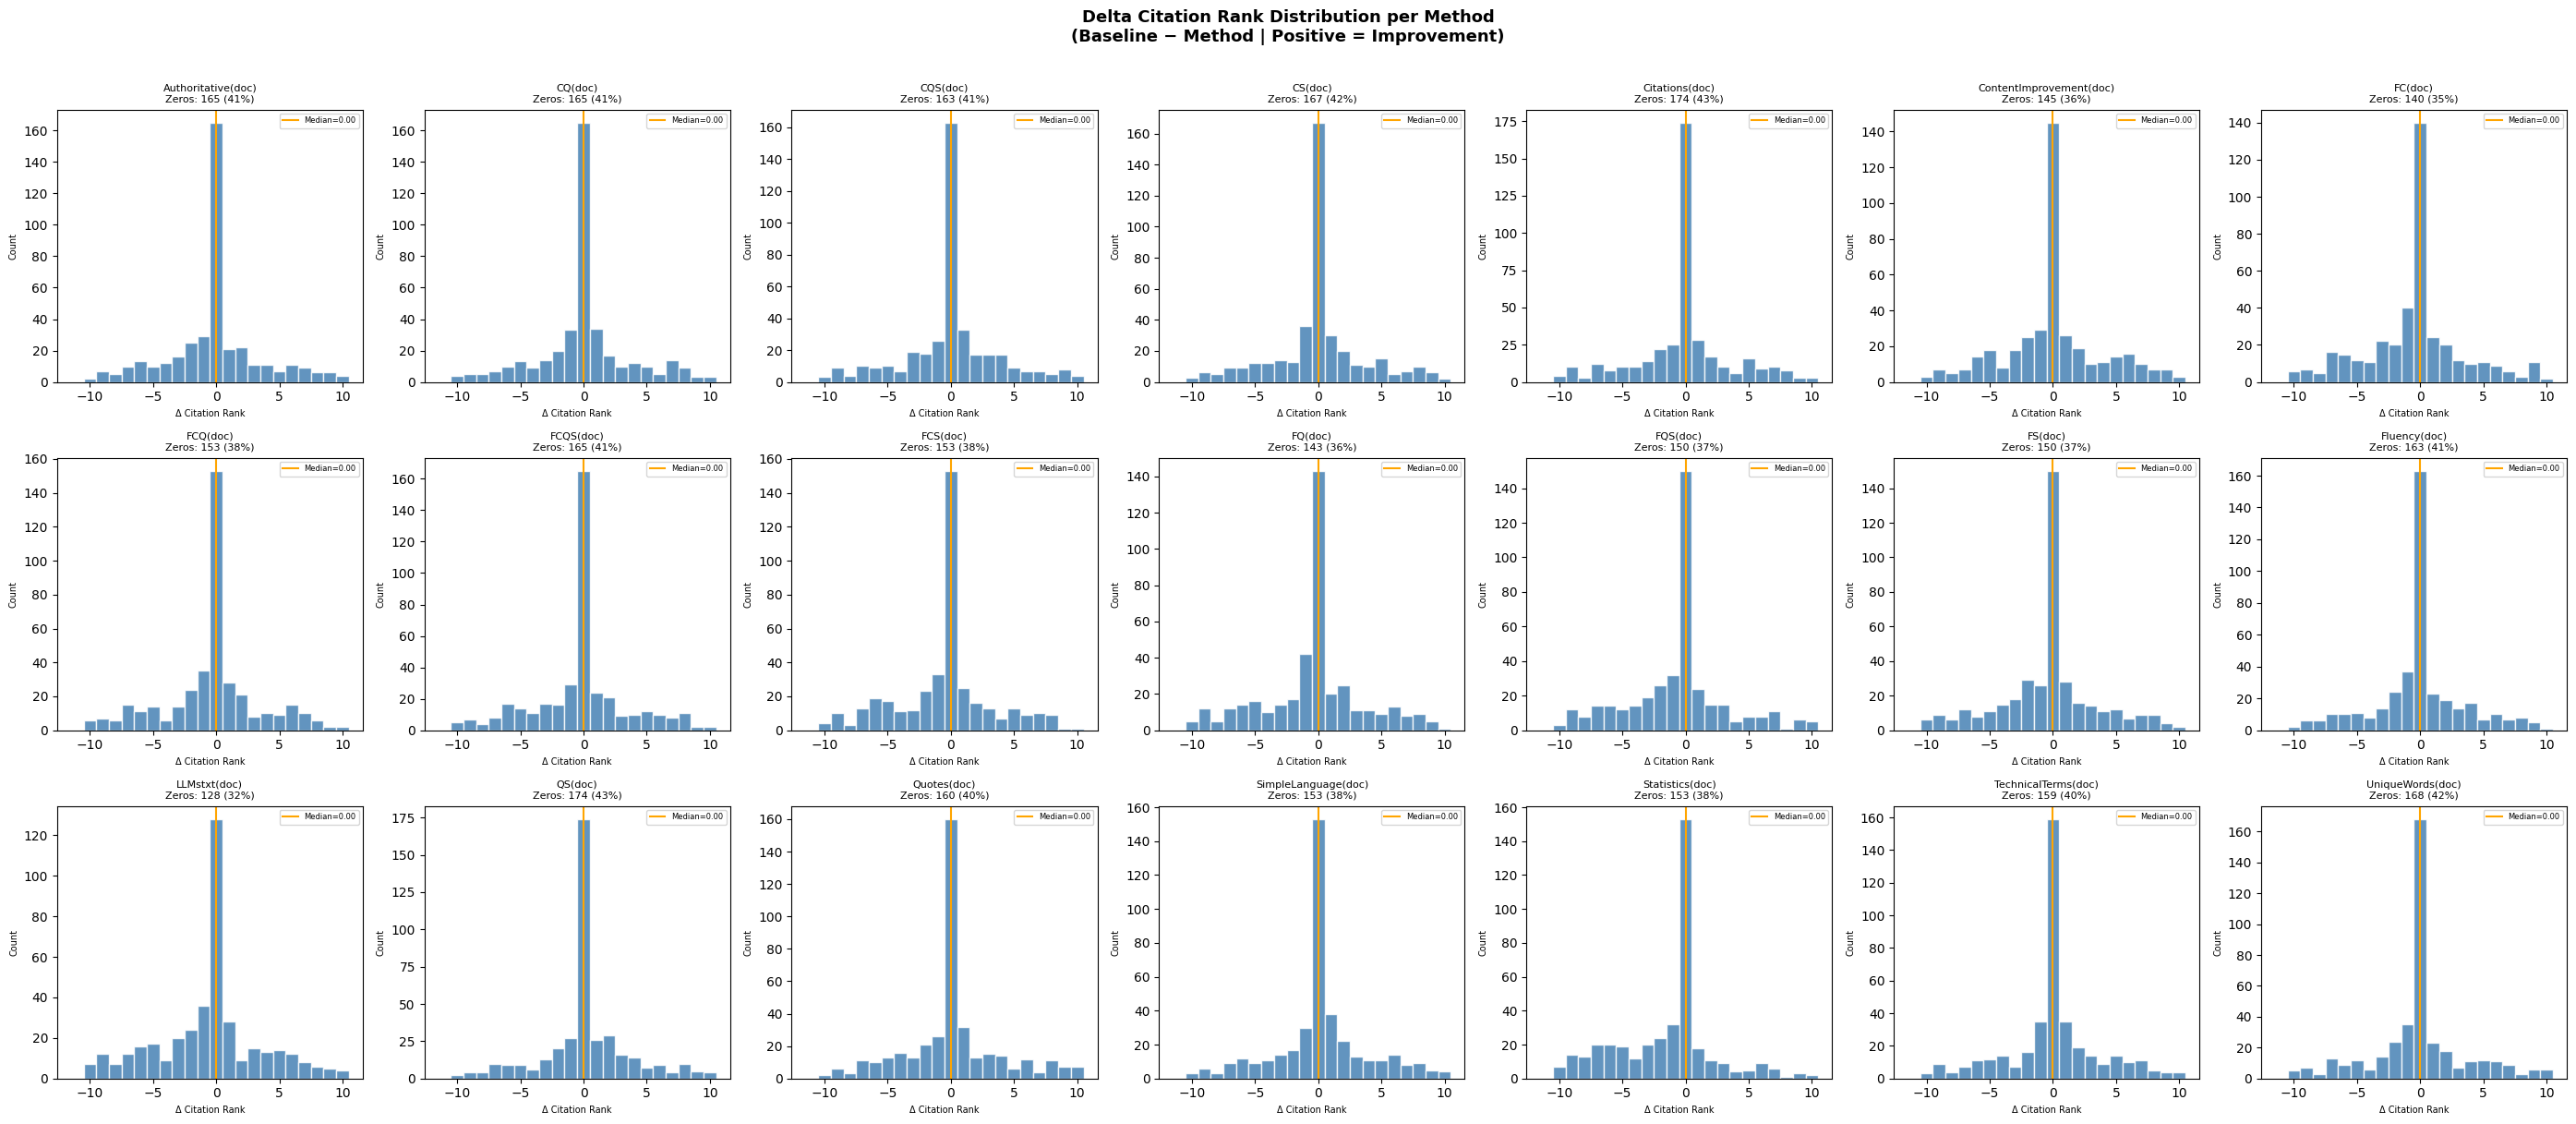

,Method,N,Zeros,% Zeros,Median,Skewness,Standardised z,Asymmetric |z|>1.96
0,Authoritative(doc),402,165,41.0,0.0,0.118,0.964,False
1,FQS(doc),402,150,37.3,0.0,0.067,0.545,False
2,TechnicalTerms(doc),402,159,39.6,0.0,-0.067,-0.547,False
3,Statistics(doc),402,153,38.1,0.0,-0.081,-0.664,False
4,SimpleLanguage(doc),402,153,38.1,0.0,0.025,0.204,False
5,Quotes(doc),402,160,39.8,0.0,0.236,1.934,False
6,QS(doc),402,174,43.3,0.0,0.073,0.596,False
7,LLMstxt(doc),402,128,31.8,0.0,-0.026,-0.212,False
8,Fluency(doc),402,163,40.5,0.0,-0.030,-0.246,False
9,FS(doc),402,150,37.3,0.0,-0.080,-0.655,False


In [30]:
from scipy.stats import skew

fig, axes = plt.subplots(3, 7, figsize=(28, 12))
axes = axes.flatten()

for idx, method in enumerate(all_methods):
    merged = base_cr.merge(
        df[df["method"] == method][["original_query_id", "target_citation_rank"]]
        .rename(columns={"target_citation_rank": "cr_method"}),
        on="original_query_id"
    )
    diffs     = (merged["cr_baseline"] - merged["cr_method"]).values
    n_zeros   = (diffs == 0).sum()
    pct_zeros = n_zeros / len(diffs) * 100

    ax = axes[idx]
    ax.hist(diffs, bins=range(-11, 12), align="left", color="steelblue", edgecolor="white", alpha=0.85)
    ax.axvline(0, color="red", linewidth=1.2, linestyle="--")
    ax.axvline(np.median(diffs), color="orange", linewidth=1.5, label=f"Median={np.median(diffs):.2f}")
    ax.set_title(f"{method}\nZeros: {n_zeros} ({pct_zeros:.0f}%)", fontsize=8)
    ax.set_xlabel("Δ Citation Rank", fontsize=7)
    ax.set_ylabel("Count", fontsize=7)
    ax.legend(fontsize=6)

for j in range(len(all_methods), len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Delta Citation Rank Distribution per Method\n(Baseline − Method | Positive = Improvement)",
             fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

# Symmetry summary table
symmetry_rows = []
for method in all_methods:
    merged = base_cr.merge(
        df[df["method"] == method][["original_query_id", "target_citation_rank"]]
        .rename(columns={"target_citation_rank": "cr_method"}),
        on="original_query_id"
    )
    diffs = (merged["cr_baseline"] - merged["cr_method"]).values
    n     = len(diffs)
    sk    = skew(diffs)
    se    = np.sqrt(6 / n)
    z     = sk / se
    symmetry_rows.append({
        "Method":              method,
        "N":                   n,
        "Zeros":               int((diffs == 0).sum()),
        "% Zeros":             round((diffs == 0).mean() * 100, 1),
        "Median":              round(float(np.median(diffs)), 3),
        "Skewness":            round(sk, 3),
        "Standardised z":      round(z, 3),
        "Asymmetric |z|>1.96": abs(z) > 1.96,
    })

symmetry_df = pd.DataFrame(symmetry_rows).sort_values("Median", ascending=False).reset_index(drop=True)
display(symmetry_df)


No method shows statistically significant skewness — all standardised z-values fall below |1.96| and `Asymmetric |z|>1.96` is False for all 21 methods. The symmetry assumption for the Wilcoxon signed-rank test is fulfilled across all 21 comparisons.

### Wilcoxon Signed-Rank Test

Tests whether each GEO method shifts citation rank relative to the baseline. For each method, paired differences (Δ = baseline − method) are computed per query and a Wilcoxon signed-rank test with Pratt modification is applied. The Pratt modification retains zero differences in the ranking step before exclusion, which matters here given that 31–43% of pairs show no shift.

`calculate_significant_improvements` returns p-values for three alternatives (greater, less, two-sided) and an effect size r = |Z| / √N derived directly from the W statistic to avoid floating-point saturation. The subsequent cell runs this function for all 21 methods, bootstraps 95% CIs for r (10,000 iterations), and applies Bonferroni-Holm correction across the 21 comparisons.

In [31]:
def calculate_significant_improvements(df_baseline, df_method):
    """
    Computes Delta Rank for each paired query:
        delta = baseline_target_citation_rank - method_target_citation_rank

    Positive = method cited target earlier (improvement).
    Negative = method cited target later (deterioration).

    Uses target_citation_rank directly (1-based, 1–10; non-cited = penalty 11).
    Both DataFrames must be pre-sorted and aligned on original_query_id.
    Applies Wilcoxon signed-rank test with Pratt modification (zeros retained).
    Adapted from Puerto (2025).
    """
    from scipy.stats import rankdata

    diffs = (
        df_baseline["target_citation_rank"].values
        - df_method["target_citation_rank"].values
    ).tolist()

    if len(diffs) == 0:
        return {"statistic": None, "pvalue_greater": None, "pvalue_less": None,
                "pvalue_twosided": None, "Delta Rank": (None, None), "diffs": [], "r_effect": None}

    stat_g, pval_g = wilcoxon(diffs, alternative="greater",   zero_method="pratt")
    stat_l, pval_l = wilcoxon(diffs, alternative="less",      zero_method="pratt")
    stat_t, pval_t = wilcoxon(diffs, alternative="two-sided", zero_method="pratt")

    median_diff = np.median(diffs)
    mean_diff   = np.mean(diffs)
    N           = len(diffs)

    # Compute Z directly from W statistic — avoids float-limit saturation from norm.ppf
    diffs_arr = np.array(diffs)
    n_z       = int((diffs_arr == 0).sum())
    ranks     = rankdata(np.abs(diffs_arr))
    w_plus    = ranks[diffs_arr > 0].sum()
    mu        = (N * (N + 1) - n_z * (n_z + 1)) / 4
    sigma     = np.sqrt((N * (N + 1) * (2 * N + 1) - n_z * (n_z + 1) * (2 * n_z + 1)) / 24)
    z_stat    = (w_plus - mu) / sigma
    r_effect  = abs(z_stat) / np.sqrt(N)

    return {
        "statistic":       stat_g,
        "pvalue_greater":  pval_g,
        "pvalue_less":     pval_l,
        "pvalue_twosided": pval_t,
        "Delta Rank":      (median_diff, mean_diff),
        "diffs":           diffs,
        "r_effect":        r_effect,
    }

In [32]:
np.random.seed(42)

def bootstrap_effect_size_delta(diffs, n_iterations=10000):
    """
    Bootstrapped 95% CI for Wilcoxon effect size r = |Z| / sqrt(N).
    Uses Pratt modification: zero-differences are ranked before exclusion.
    Z computed directly from W statistic.
    """
    from scipy.stats import rankdata
    diffs = np.array(diffs)
    n     = len(diffs)
    boot_effects = []

    for _ in range(n_iterations):
        idx        = np.random.choice(n, size=n, replace=True)
        boot_diffs = diffs[idx]
        n_z        = int((boot_diffs == 0).sum())
        if n_z == n:
            continue
        ranks  = rankdata(np.abs(boot_diffs))
        w_plus = ranks[boot_diffs > 0].sum()
        mu     = (n * (n + 1) - n_z * (n_z + 1)) / 4
        sigma  = np.sqrt((n * (n + 1) * (2 * n + 1) - n_z * (n_z + 1) * (2 * n_z + 1)) / 24)
        z_stat = (w_plus - mu) / sigma
        boot_effects.append(abs(z_stat) / np.sqrt(n))

    return np.percentile(boot_effects, 2.5), np.percentile(boot_effects, 97.5)


def fmt_p(p):
    if p is None:
        return "—"
    if p == 0.0:
        return "< 1e-300"
    return f"{p:.2e}" if p < 0.001 else f"{p:.4f}"


def sig_stars(p):
    if p is None:
        return "—"
    if p < 0.001: return "***"
    if p < 0.01:  return "**"
    if p < 0.05:  return "*"
    return "ns"


results_delta = []
for method in all_methods:
    df_m   = df[df["method"] == method].sort_values("original_query_id").reset_index(drop=True)
    df_b_a = df_baseline.sort_values("original_query_id").reset_index(drop=True)
    res    = calculate_significant_improvements(df_b_a, df_m)

    ci_lower, ci_upper = bootstrap_effect_size_delta(res["diffs"])

    results_delta.append({
        "method":                 method,
        "n_queries":              len(df_m),
        "delta_citation_rank":      res["Delta Rank"][0],
        "delta_citation_rank_mean": res["Delta Rank"][1],
        "pvalue_greater":         res["pvalue_greater"],
        "pvalue_less":            res["pvalue_less"],
        "pvalue_twosided":        res["pvalue_twosided"],
        "r_effect":               res["r_effect"],
        "ci_lower":               ci_lower,
        "ci_upper":               ci_upper,
        "diffs":                  res["diffs"],
    })

df_results = pd.DataFrame(results_delta).sort_values("delta_citation_rank_mean", ascending=False)

_, pg_holm, _, _ = multipletests(df_results["pvalue_greater"].values, method="holm")
df_results["pvalue_greater_holm"] = pg_holm

print("Confirmatory — Wilcoxon One-Sided (greater) + Pratt")
print("Bonferroni-Holm correction applied across 21 comparisons")
print()
print(f"{'Method':<30} {'Med.Shift':>10} {'Mean.Shift':>11} {'p':>11} {'Sig':>5} {'p (Holm)':>12} {'Sig':>5} {'r':>7} {'95% CI':>18}")
print("-" * 119)
for _, row in df_results.iterrows():
    ci_str = f"[{row['ci_lower']:+.3f}, {row['ci_upper']:+.3f}]"
    print(
        f"  {row['method']:<28} {row['delta_citation_rank']:>10.3f} {row['delta_citation_rank_mean']:>+11.3f}"
        f" {fmt_p(row['pvalue_greater']):>11} {sig_stars(row['pvalue_greater']):>5}"
        f" {fmt_p(row['pvalue_greater_holm']):>12} {sig_stars(row['pvalue_greater_holm']):>5}"
        f" {row['r_effect']:>7.4f} {ci_str:>18}"
    )
print()
print("Med.Shift = median(baseline \u2212 method) delta_citation_rank. Positive = cited earlier.")
print("Effect size r = |Z| / \u221aN: 0.1 = small, 0.3 = medium, 0.5 = large.")

Confirmatory — Wilcoxon One-Sided (greater) + Pratt
Bonferroni-Holm correction applied across 21 comparisons

Method                          Med.Shift  Mean.Shift           p   Sig     p (Holm)   Sig       r             95% CI
-----------------------------------------------------------------------------------------------------------------------
  QS(doc)                           0.000      +0.206      0.0869    ns       1.0000    ns  0.0678   [+0.004, +0.166]
  SimpleLanguage(doc)               0.000      +0.197      0.1052    ns       1.0000    ns  0.0624   [+0.004, +0.158]
  Quotes(doc)                       0.000      +0.097      0.4569    ns       1.0000    ns  0.0054   [+0.001, +0.114]
  TechnicalTerms(doc)               0.000      +0.030      0.3475    ns       1.0000    ns  0.0195   [+0.002, +0.118]
  CQS(doc)                          0.000      +0.025      0.3363    ns       1.0000    ns  0.0211   [+0.002, +0.122]
  CQ(doc)                           0.000      +0.007      0.5

No GEO method significantly improves citation rank after Bonferroni-Holm correction. The two best-performing methods — QS(doc) and SimpleLanguage(doc) — have uncorrected p-values of 0.087 and 0.105, both above α = 0.05 even before correction, with small effect sizes (r = 0.068 and 0.062). **H2 is not supported:** GEO edits do not reliably improve citation visibility.

In [33]:
_, pl_holm, _, _ = multipletests(df_results["pvalue_less"].values, method="holm")
df_results["pvalue_less_holm"] = pl_holm

print("Post Hoc Exploratory — Wilcoxon One-Sided (less) + Pratt")
print("Bonferroni-Holm correction applied across 21 comparisons")
print()
print(f"{'Method':<30} {'Med.Shift':>10} {'Mean.Shift':>11} {'p':>11} {'Sig':>5} {'p (Holm)':>12} {'Sig':>5} {'r':>7} {'95% CI':>18}")
print("-" * 119)
for _, row in df_results.iterrows():
    ci_str = f"[{row['ci_lower']:+.3f}, {row['ci_upper']:+.3f}]"
    print(
        f"  {row['method']:<28} {row['delta_citation_rank']:>10.3f} {row['delta_citation_rank_mean']:>+11.3f}"
        f" {fmt_p(row['pvalue_less']):>11} {sig_stars(row['pvalue_less']):>5}"
        f" {fmt_p(row['pvalue_less_holm']):>12} {sig_stars(row['pvalue_less_holm']):>5}"
        f" {row['r_effect']:>7.4f} {ci_str:>18}"
    )
print()
print("Med.Shift = median(baseline \u2212 method) delta_citation_rank. Negative = method worsened position.")
print("Effect size r = |Z| / \u221aN: 0.1 = small, 0.3 = medium, 0.5 = large.")

Post Hoc Exploratory — Wilcoxon One-Sided (less) + Pratt
Bonferroni-Holm correction applied across 21 comparisons

Method                          Med.Shift  Mean.Shift           p   Sig     p (Holm)   Sig       r             95% CI
-----------------------------------------------------------------------------------------------------------------------
  QS(doc)                           0.000      +0.206      0.9131    ns       1.0000    ns  0.0678   [+0.004, +0.166]
  SimpleLanguage(doc)               0.000      +0.197      0.8948    ns       1.0000    ns  0.0624   [+0.004, +0.158]
  Quotes(doc)                       0.000      +0.097      0.5431    ns       1.0000    ns  0.0054   [+0.001, +0.114]
  TechnicalTerms(doc)               0.000      +0.030      0.6525    ns       1.0000    ns  0.0195   [+0.002, +0.118]
  CQS(doc)                          0.000      +0.025      0.6637    ns       1.0000    ns  0.0211   [+0.002, +0.122]
  CQ(doc)                           0.000      +0.007    

Two methods significantly harm citation rank after Bonferroni-Holm correction:

- **Statistics(doc):** p = 5.98e-14, p_holm = 1.26e-12 (***), r = 0.370 — a medium effect. Adding statistics to the document consistently pushes the target to a later citation position or out of the citation list entirely.
- **FQS(doc):** p = 2.07e-04, p_holm = 0.004 (**), r = 0.176 — a small effect.

Several other F-prefix methods (FC, FCS, LLMstxt) reach nominal significance but do not survive correction. Overall, the evidence is one-directional: GEO edits do not reliably improve citation visibility, but certain edit types — particularly Statistics-based combinations — significantly worsen it.